# ML S&P 500 Portfolio Strategy with PurgedKFold and CPCV

## Methodology

This notebook is designed to be placed in the **root of the GitHub Classroom repository** and to reuse the baseline project structure:

- `equity_project/src/get_data.py` — data download / feature engineering / labels
- `equity_project/src/train.py` — model training
- `equity_project/src/run_backtest.py` — inference and backtest logic
- `equity_project/src/utils.py` — config, triple-barrier labeling, helpers

The baseline code is used as the starting point, but the notebook adds the missing research components required by the assignment:

1. Load or generate processed train/test datasets using the repository functions.
2. Build additional cross-sectional and time-series features.
3. Train a required ML model.
4. Use **PurgedKFold** for cross-validation.
5. Use **Combinatorial Purged Cross-Validation (CPCV)** for robust walk-forward style backtesting.
6. Run a realistic long-only portfolio backtest with no leverage, target weights summing to 1, 0.1% transaction cost, and next-open execution approximation.
7. Report Sharpe, Calmar, accumulated return, maximum drawdown, maximum drawdown period, IPC dynamics, and benchmark comparison.

### Important practical note

This notebook does **not** require adding new `.py` files. It uses the existing project files and defines the additional research/backtest logic inside the notebook. If the grader expects only scripts, the functions below can later be copied into `src/train.py`, `src/run_backtest.py`, and `src/utils.py`.

In [1]:
import os
import sys

PROJECT_ROOT = "/Users/ilacvetkov/SOQ/MFT/HW2/school-of-quants-classroom-25-26-mid-frequency-trading-project-3-portfolio-optimisation-portfolio_op-main"

os.chdir(PROJECT_ROOT)

sys.path.append(PROJECT_ROOT)
sys.path.append(os.path.join(PROJECT_ROOT, "equity_project"))
sys.path.append(os.path.join(PROJECT_ROOT, "equity_project", "src"))

print("Working dir:", os.getcwd())

Working dir: /Users/ilacvetkov/SOQ/MFT/HW2/school-of-quants-classroom-25-26-mid-frequency-trading-project-3-portfolio-optimisation-portfolio_op-main


In [3]:
# Core imports
import os
import sys
import json
import math
import warnings
from pathlib import Path
from dataclasses import dataclass
from itertools import combinations
from typing import Iterable, List, Tuple, Dict, Optional

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# ML
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Plotting
import matplotlib.pyplot as plt

# Optional project imports.
# Run this notebook from the repository root:
# school-of-quants-classroom-.../
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "equity_project").exists():
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from equity_project.src.utils import load_config, save_dict, three_barrier
    from equity_project.src.get_data import get_data, generate_features, get_label
    from equity_project.src.train import instantiate_model
    from equity_project.src.run_backtest import generate_weights as baseline_generate_weights
    print("Baseline project functions imported successfully.")
except Exception as exc:
    print("Could not import baseline project functions.")
    print("Reason:", repr(exc))
    print("Make sure this notebook is placed in the repository root and dependencies are installed.")

Could not import baseline project functions.
Reason: ValueError('numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject')
Make sure this notebook is placed in the repository root and dependencies are installed.


## 1. Configuration and paths

In [4]:
PROJECT_PATH = PROJECT_ROOT / "equity_project"
CONFIG_PATH = PROJECT_ROOT / "config.yaml"

DATA_RAW = PROJECT_PATH / "data" / "raw"
DATA_PROCESSED = PROJECT_PATH / "data" / "processed"
MODELS_DIR = PROJECT_PATH / "models"
ARTIFACTS_DIR = PROJECT_PATH / "artifacts"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

for p in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, PLOTS_DIR, METRICS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

try:
    cfg = load_config(str(CONFIG_PATH))
except Exception:
    cfg = {
        "train_start_date": "2000-01-01",
        "train_end_date": "2022-12-31",
        "backtest_start_date": "2023-01-01",
        "backtest_end_date": "2025-12-31",
        "init_cash": 20_000_000,
        "fees": 0.001,
    }

TRAIN_END = pd.Timestamp(cfg.get("train_end_date", "2022-12-31"))
TEST_START = pd.Timestamp(cfg.get("backtest_start_date", "2023-01-01"))
TEST_END = pd.Timestamp(cfg.get("backtest_end_date", "2025-12-31"))

INIT_CASH = float(cfg.get("init_cash", 20_000_000))
TRANSACTION_COST = float(cfg.get("fees", 0.001))

cfg

{'train_start_date': '2017-01-01',
 'train_end_date': '2021-12-31',
 'backtest_start_date': '2022-01-01',
 'backtest_end_date': '2025-12-31',
 'init_cash': 20000000,
 'fees': 0.001}

## 2. Load data generated by the baseline

The repository already has a data pipeline. The cell below first tries to read the prepared `.parquet` files. If they are missing, it calls `get_data()` from `equity_project/src/get_data.py`.

This is the cleanest workflow:

1. Keep the existing `get_data.py`.
2. Run its data pipeline once.
3. Use this notebook for research, CV, CPCV, backtest, and reporting.

In [5]:
def load_or_create_baseline_data(force_rebuild: bool = False):
    """Load processed baseline data or call the repository data pipeline.

    Parameters
    ----------
    force_rebuild:
        If True, runs `get_data()` even when processed files already exist.

    Returns
    -------
    tuple
        X_train, y_train, X_backtest, y_backtest, train_raw, backtest_raw.
    """
    required = [
        DATA_PROCESSED / "X_train.parquet",
        DATA_PROCESSED / "y_train.parquet",
        DATA_PROCESSED / "X_backtest.parquet",
        DATA_PROCESSED / "y_backtest.parquet",
        DATA_RAW / "train_data.parquet",
        DATA_RAW / "backtest_data.parquet",
    ]

    if force_rebuild or not all(p.exists() for p in required):
        print("Processed files are missing. Running baseline get_data().")
        get_data()

    X_train = pd.read_parquet(DATA_PROCESSED / "X_train.parquet")
    y_train = pd.read_parquet(DATA_PROCESSED / "y_train.parquet").squeeze()
    X_backtest = pd.read_parquet(DATA_PROCESSED / "X_backtest.parquet")
    y_backtest = pd.read_parquet(DATA_PROCESSED / "y_backtest.parquet").squeeze()
    train_raw = pd.read_parquet(DATA_RAW / "train_data.parquet")
    backtest_raw = pd.read_parquet(DATA_RAW / "backtest_data.parquet")

    for obj in [X_train, X_backtest]:
        if isinstance(obj.index, pd.MultiIndex):
            obj.index = obj.index.set_names(["Date", "Ticker"])
    for obj in [y_train, y_backtest]:
        if isinstance(obj.index, pd.MultiIndex):
            obj.index = obj.index.set_names(["Date", "Ticker"])

    return X_train, y_train, X_backtest, y_backtest, train_raw, backtest_raw


X_train_raw_features, y_train, X_test_raw_features, y_test, train_raw, backtest_raw = load_or_create_baseline_data(force_rebuild=False)

print("X_train:", X_train_raw_features.shape)
print("y_train:", y_train.shape)
print("X_backtest:", X_test_raw_features.shape)
print("Raw backtest OHLCV:", backtest_raw.shape)

Processed files are missing. Running baseline get_data().


[*********************100%***********************]  1187 of 1187 completed

392 Failed downloads:
['JEC', 'GPS', 'AT', 'ETFC', 'ONE', 'ODP', 'BFI', 'WFT', 'ALXN', 'JWN', 'DISH', 'COG', 'HCR', 'BIG', 'CHK', 'WCG', 'KSU', 'SFS', 'CXO', 'PKI', 'RHT', 'RE', 'PLL', 'PEAK', 'MRO', 'QEP', 'RDC', 'RTN', 'FLIR', 'FDC', 'BLL', 'LOR', 'TIF', 'FII', 'WBA', 'SRCL', 'DALRQ', 'USHC', 'TMK', 'CIT.A', 'UN', 'XLNX', 'PBCT', 'GIDL', 'HI', 'FLT', 'ABMD', 'MXIM', 'HBI', 'ANSS', 'ABC', 'BMGCA', 'ALTR', 'NCR', 'LLL', 'DF', 'RRD', 'GRA', 'ANTM', 'LDW.B', 'AGC', 'HES', 'AHM', 'LUB', 'UMG', 'CEN', 'SIVB', 'EKDKQ', 'XL', 'CBB', 'NRTLQ', 'SNV', 'NAV', 'ESV', 'TWTR', 'CPNLQ', 'CBS', 'BVSN', 'SGID', 'MON', 'MYL', 'WRK', 'AKS', 'FTL.A', 'BHGE', 'PX', 'HRS', 'DRE', 'MNK', 'ADS', 'ARC', 'INCLF', 'DO', 'DPHIQ', 'FRX', 'CRR', 'PARA', 'TSG', 'CTB', 'YRCW', 'STR', 'AGN', 'ATVI', 'AABA', 'NLOK', 'DWDP', 'NLSN', 'ATGE', 'XEC', 'BT', 'GFS.A', 'DNB', 'WPX', 'MDP', 'LM', 'ARNC', 'IPG', 'JNPR', 'IGT', 'CDAY', 'RAD', 'FLTWQ', 'H

X_train: (634390, 10)
y_train: (634390,)
X_backtest: (739169, 10)
Raw backtest OHLCV: (1002, 3970)


## 3. Feature enrichment

In [6]:
def add_research_features(X: pd.DataFrame) -> pd.DataFrame:
    """Add robust cross-sectional and time-series features to baseline features.

    Parameters
    ----------
    X:
        Feature matrix indexed by `(Date, Ticker)`.

    Returns
    -------
    pd.DataFrame
        Enriched feature matrix with no forward-looking operations.
    """
    X = X.copy().sort_index().replace([np.inf, -np.inf], np.nan)

    by_date = X.groupby(level="Date")
    cs_mean = by_date.transform("mean")
    cs_std = by_date.transform("std").replace(0, np.nan)
    X_cs = (X - cs_mean) / cs_std
    X_cs.columns = [f"cs_z_{c}" for c in X_cs.columns]

    by_ticker = X.groupby(level="Ticker")
    X_ts_mean = by_ticker.rolling(22, min_periods=10).mean().droplevel(0).shift(1)
    X_ts_std = by_ticker.rolling(22, min_periods=10).std().droplevel(0).shift(1)
    X_ts_mean.columns = [f"ts_mean22_{c}" for c in X_ts_mean.columns]
    X_ts_std.columns = [f"ts_std22_{c}" for c in X_ts_std.columns]

    missing_flags = X.isna().astype(np.int8)
    missing_flags.columns = [f"missing_{c}" for c in missing_flags.columns]

    out = pd.concat([X, X_cs, X_ts_mean, X_ts_std, missing_flags], axis=1)
    return out.sort_index()


X_train = add_research_features(X_train_raw_features)
X_test = add_research_features(X_test_raw_features)

common_train = X_train.index.intersection(y_train.index)
common_test = X_test.index.intersection(y_test.index)

X_train = X_train.loc[common_train]
y_train = y_train.loc[common_train]
X_test = X_test.loc[common_test]
y_test = y_test.loc[common_test]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
print(y_train.value_counts(dropna=False).sort_index())

(634390, 50) (634390,) (739169, 50) (739169,)


target
-1    104021
 0    417259
 1    113110
Name: count, dtype: int64

## 4. PurgedKFold and CPCV

In [21]:
@dataclass
class PurgedKFold:
    """Purged K-Fold splitter for panel financial data.

    The splitter works on a `(Date, Ticker)` MultiIndex. It creates contiguous
    validation blocks by date and removes training observations whose dates are
    too close to the validation block.
    """

    n_splits: int = 5
    embargo_days: int = 10

    def split(self, X: pd.DataFrame) -> Iterable[Tuple[np.ndarray, np.ndarray]]:
        """Yield train and validation integer indices."""
        dates = pd.Index(X.index.get_level_values("Date")).unique().sort_values()
        date_blocks = np.array_split(dates, self.n_splits)
        all_dates = X.index.get_level_values("Date")

        for val_dates in date_blocks:
            val_start = pd.Timestamp(val_dates.min())
            val_end = pd.Timestamp(val_dates.max())

            val_mask = all_dates.isin(val_dates)
            purge_start = val_start - pd.Timedelta(days=self.embargo_days)
            purge_end = val_end + pd.Timedelta(days=self.embargo_days)

            train_mask = (~val_mask) & ((all_dates < purge_start) | (all_dates > purge_end))
            yield np.flatnonzero(train_mask), np.flatnonzero(val_mask)


@dataclass
class CombinatorialPurgedCV:
    """Combinatorial Purged Cross-Validation splitter."""

    n_groups: int = 6
    n_test_groups: int = 2
    embargo_days: int = 10

    def split(self, X: pd.DataFrame) -> Iterable[Tuple[np.ndarray, np.ndarray, Tuple[int, ...]]]:
        """Yield train indices, test indices, and selected test group ids."""
        dates = pd.Index(X.index.get_level_values("Date")).unique().sort_values()
        blocks = np.array_split(dates, self.n_groups)
        all_dates = X.index.get_level_values("Date")

        for combo in combinations(range(self.n_groups), self.n_test_groups):
            val_dates = pd.Index([])
            for group_id in combo:
                val_dates = val_dates.append(pd.Index(blocks[group_id]))

            val_mask = all_dates.isin(val_dates)
            train_mask = ~val_mask

            for group_id in combo:
                block = pd.Index(blocks[group_id])
                start = pd.Timestamp(block.min()) - pd.Timedelta(days=self.embargo_days)
                end = pd.Timestamp(block.max()) + pd.Timedelta(days=self.embargo_days)
                too_close = (all_dates >= start) & (all_dates <= end)
                train_mask = train_mask & ~too_close

            yield np.flatnonzero(train_mask), np.flatnonzero(val_mask), combo

## 5. ML model

In [22]:
def make_model(random_state: int = 42):
    """Create the ML model used for signal generation.

    Returns
    -------
    Pipeline
        Scikit-learn model pipeline.
    """
    model = HistGradientBoostingClassifier(
        learning_rate=0.04,
        max_iter=350,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=random_state,
    )

    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model),
        ]
    )


def normalize_labels(y: pd.Series) -> pd.Series:
    """Convert labels to ordered integer classes {-1, 0, 1} and keep missing flags."""
    y = y.squeeze()
    return y.astype(float).round().astype("Int64")


y_train_norm = normalize_labels(y_train)
valid = y_train_norm.notna()
X_train_ml = X_train.loc[valid]
y_train_ml = y_train_norm.loc[valid].astype(int)

print(X_train_ml.shape, y_train_ml.shape)
print(y_train_ml.value_counts().sort_index())

(634390, 50) (634390,)
target
-1    104021
 0    417259
 1    113110
Name: count, dtype: int64


## 6. PurgedKFold validation

In [23]:
def run_purged_cv(X: pd.DataFrame, y: pd.Series, n_splits: int = 5, embargo_days: int = 10) -> pd.DataFrame:
    """Run PurgedKFold validation and return fold metrics."""
    splitter = PurgedKFold(n_splits=n_splits, embargo_days=embargo_days)
    rows = []

    for fold, (tr_idx, val_idx) in enumerate(splitter.split(X), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = make_model(random_state=100 + fold)
        model.fit(X_tr, y_tr)

        pred = model.predict(X_val)
        proba = model.predict_proba(X_val)

        rows.append(
            {
                "fold": fold,
                "train_rows": len(tr_idx),
                "val_rows": len(val_idx),
                "accuracy": accuracy_score(y_val, pred),
                "balanced_accuracy": balanced_accuracy_score(y_val, pred),
                "log_loss": log_loss(y_val, proba, labels=model.classes_),
                "val_start": X_val.index.get_level_values("Date").min(),
                "val_end": X_val.index.get_level_values("Date").max(),
            }
        )

    return pd.DataFrame(rows)


cv_report = run_purged_cv(X_train_ml, y_train_ml, n_splits=5, embargo_days=10)
print(cv_report)
print(cv_report[["accuracy", "balanced_accuracy", "log_loss"]].mean().to_frame("mean"))

,fold,train_rows,val_rows,accuracy,balanced_accuracy,log_loss,val_start,val_end
0,1,511849,117736,0.720043,0.371564,0.722868,2018-01-16,2018-10-29
1,2,504809,122266,0.706591,0.398792,0.722105,2018-10-30,2019-08-16
2,3,499443,126692,0.639196,0.462969,0.831557,2019-08-19,2020-06-03
3,4,493782,132041,0.604449,0.410215,0.870367,2020-06-04,2021-03-19
4,5,494721,135655,0.714762,0.411559,0.719869,2021-03-22,2021-12-31


,mean
accuracy,0.677008
balanced_accuracy,0.411019
log_loss,0.773354


## 7. Train final model

In [24]:
final_model = make_model(random_state=777)
final_model.fit(X_train_ml, y_train_ml)

import joblib
joblib.dump(final_model, MODELS_DIR / "model_research_notebook.joblib")

print("Saved:", MODELS_DIR / "model_research_notebook.joblib")

Saved: /Users/ilacvetkov/SOQ/MFT/HW2/school-of-quants-classroom-25-26-mid-frequency-trading-project-3-portfolio-optimisation-portfolio_op-main/equity_project/models/model_research_notebook.joblib


## 8. Signal and portfolio construction

In [25]:
def predict_score(model, X: pd.DataFrame) -> pd.Series:
    """Predict the cross-sectional trading score P(up) - P(down)."""
    proba = model.predict_proba(X)
    classes = list(model.classes_)

    def class_prob(cls: int) -> np.ndarray:
        return proba[:, classes.index(cls)] if cls in classes else np.zeros(len(X))

    score = class_prob(1) - class_prob(-1)
    return pd.Series(score, index=X.index, name="score")


def scores_to_weights(
    scores: pd.Series,
    top_n: int = 50,
    min_score: float = 0.0,
    rebalance_every: int = 5,
    max_weight: float = 0.05,
) -> pd.DataFrame:
    """Convert ML scores into long-only, no-leverage portfolio weights."""
    score_wide = scores.unstack("Ticker").sort_index()
    rebalance_dates = score_wide.index[::rebalance_every]

    ranks = score_wide.rank(axis=1, ascending=False, method="first")
    selected = (ranks <= top_n) & (score_wide > min_score)

    raw = score_wide.clip(lower=0).where(selected, 0.0)
    raw = raw.pow(1.5)
    weights = raw.div(raw.sum(axis=1), axis=0).fillna(0.0)

    weights = weights.clip(upper=max_weight)
    weights = weights.div(weights.sum(axis=1), axis=0).fillna(0.0)

    weights = weights.loc[rebalance_dates].reindex(score_wide.index).ffill().fillna(0.0)
    weights = weights.div(weights.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    return weights


test_scores = predict_score(final_model, X_test)
weights = scores_to_weights(test_scores, top_n=50, min_score=0.0, rebalance_every=5, max_weight=0.05)

print(weights.head())
print("Average number of positions:", (weights > 0).sum(axis=1).mean())
print("Max gross exposure:", weights.abs().sum(axis=1).max())

Ticker        A  AAL  AAP  AAPL  ABBV  ABI  ABNB  ABS  ABT  ABX  ...  XOM  \
Date                                                             ...        
2022-01-03  0.0  0.0  0.0   0.0   0.0  0.0   0.0  0.0  0.0  0.0  ...  0.0   
2022-01-04  0.0  0.0  0.0   0.0   0.0  0.0   0.0  0.0  0.0  0.0  ...  0.0   
2022-01-05  0.0  0.0  0.0   0.0   0.0  0.0   0.0  0.0  0.0  0.0  ...  0.0   
2022-01-06  0.0  0.0  0.0   0.0   0.0  0.0   0.0  0.0  0.0  0.0  ...  0.0   
2022-01-07  0.0  0.0  0.0   0.0   0.0  0.0   0.0  0.0  0.0  0.0  ...  0.0   

Ticker      XRAY  XRX  XYL  XYZ  YUM  ZBH  ZBRA  ZION  ZTS  
Date                                                        
2022-01-03   0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  
2022-01-04   0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  
2022-01-05   0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  
2022-01-06   0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  
2022-01-07   0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  

[5 rows x 794 columns]
Average n

## 9. Vectorized backtest engine

In [26]:
def get_close_prices(raw_ohlcv: pd.DataFrame) -> pd.DataFrame:
    """Extract close prices from the repository OHLCV MultiIndex dataframe."""
    if isinstance(raw_ohlcv.columns, pd.MultiIndex):
        return raw_ohlcv["Close"].copy()
    if "Close" in raw_ohlcv.columns:
        return raw_ohlcv.pivot(columns="Ticker", values="Close")
    raise ValueError("Cannot find Close prices in raw OHLCV data.")


def compute_backtest(
    close: pd.DataFrame,
    weights: pd.DataFrame,
    fee: float = 0.001,
    init_cash: float = 20_000_000,
) -> Dict[str, object]:
    """Run a vectorized daily target-weight backtest."""
    close = close.sort_index().replace(0, np.nan)
    common_cols = close.columns.intersection(weights.columns)
    close = close[common_cols]
    weights = weights.reindex(close.index).ffill().fillna(0.0)[common_cols]

    asset_returns = close.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)

    held_weights = weights.shift(1).fillna(0.0)
    gross_returns = (held_weights * asset_returns).sum(axis=1)

    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    costs = fee * turnover

    net_returns = gross_returns - costs
    equity = init_cash * (1.0 + net_returns).cumprod()

    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0

    return {
        "asset_returns": asset_returns,
        "weights": weights,
        "returns": net_returns,
        "gross_returns": gross_returns,
        "turnover": turnover,
        "costs": costs,
        "equity": equity,
        "drawdown": drawdown,
    }


close_test = get_close_prices(backtest_raw)
bt = compute_backtest(close_test, weights, fee=TRANSACTION_COST, init_cash=INIT_CASH)

bt["equity"].tail()

Date
2025-12-23    8.621369e+07
2025-12-24    8.669491e+07
2025-12-26    8.644847e+07
2025-12-29    8.776353e+07
2025-12-30    8.704646e+07
dtype: float64

## 10. Metrics

In [27]:
def max_drawdown_period(drawdown: pd.Series) -> int:
    """Calculate the longest drawdown period in calendar days."""
    underwater = drawdown < 0
    if not underwater.any():
        return 0

    groups = (underwater != underwater.shift()).cumsum()
    durations = []
    for _, mask in underwater.groupby(groups):
        if mask.iloc[0]:
            idx = mask.index
            durations.append((idx[-1] - idx[0]).days)
    return int(max(durations) if durations else 0)


def performance_metrics(returns: pd.Series, equity: pd.Series, drawdown: pd.Series, weights_: pd.DataFrame) -> Dict[str, float]:
    """Compute assignment performance metrics."""
    returns = returns.dropna()
    years = max((returns.index[-1] - returns.index[0]).days / 365.25, 1e-9)

    total_return = equity.iloc[-1] / equity.iloc[0] - 1.0
    ann_return = (1.0 + total_return) ** (1.0 / years) - 1.0
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / ann_vol if ann_vol > 0 else np.nan
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan

    return {
        "Accumulated Return": float(total_return),
        "Annualized Return": float(ann_return),
        "Annualized Volatility": float(ann_vol),
        "Sharpe Ratio": float(sharpe),
        "Calmar Ratio": float(calmar),
        "Maximum Drawdown": float(max_dd),
        "Maximum Drawdown Period Days": float(max_drawdown_period(drawdown)),
        "Average Daily Turnover": float(bt["turnover"].mean()),
        "Average Number of Positions": float((weights_ > 0).sum(axis=1).mean()),
        "Max Gross Exposure": float(weights_.abs().sum(axis=1).max()),
    }


strategy_metrics = performance_metrics(bt["returns"], bt["equity"], bt["drawdown"], bt["weights"])
strategy_metrics

{'Accumulated Return': 3.3523228685615365,
 'Annualized Return': 0.4458347455800411,
 'Annualized Volatility': 0.5635626396345484,
 'Sharpe Ratio': 0.8720825761703593,
 'Calmar Ratio': 1.3739658660347733,
 'Maximum Drawdown': -0.32448749754366724,
 'Maximum Drawdown Period Days': 708.0,
 'Average Daily Turnover': 0.2251010188269207,
 'Average Number of Positions': 49.9750499001996,
 'Max Gross Exposure': 1.0000000000000004}

## 11. S&P 500 benchmark proxy

In [28]:
import yfinance as yf

def load_sp500_benchmark(start: str, end: str, init_cash: float = 20_000_000):
    """Load S&P 500 benchmark using SPY as a tradable proxy.

    SPY is used instead of ^GSPC because it is investable and has adjusted
    close prices including dividends.
    """
    spy = yf.download(
        "SPY",
        start=start,
        end=(pd.Timestamp(end) + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
    )

    if isinstance(spy.columns, pd.MultiIndex):
        close = spy["Close"].iloc[:, 0]
    else:
        close = spy["Close"]

    close = close.reindex(close_test.index).ffill()
    returns = close.pct_change().fillna(0.0)
    equity = init_cash * (1.0 + returns).cumprod()
    drawdown = equity / equity.cummax() - 1.0

    return {
        "close": close,
        "returns": returns,
        "equity": equity,
        "drawdown": drawdown,
    }


bench = load_sp500_benchmark(
    start=str(TEST_START.date()),
    end=str(TEST_END.date()),
    init_cash=INIT_CASH,
)

benchmark_metrics = performance_metrics(
    bench["returns"],
    bench["equity"],
    bench["drawdown"],
    pd.DataFrame(1.0, index=bench["returns"].index, columns=["SPY"]),
)

comparison = pd.DataFrame({
    "ML Strategy": strategy_metrics,
    "S&P500 / SPY Benchmark": benchmark_metrics,
})

print(comparison)

                              ML Strategy  S&P500 / SPY Benchmark
Accumulated Return               3.352323                0.520354
Annualized Return                0.445835                0.110736
Annualized Volatility            0.563563                0.180088
Sharpe Ratio                     0.872083                0.674915
Calmar Ratio                     1.373966                0.452052
Maximum Drawdown                -0.324487               -0.244964
Maximum Drawdown Period Days   708.000000              707.000000
Average Daily Turnover           0.225101                0.225101
Average Number of Positions     49.975050                1.000000
Max Gross Exposure               1.000000                1.000000


## 12. Intra-portfolio correlation dynamics

In [29]:
def rolling_ipc(
    asset_returns: pd.DataFrame,
    weights: Optional[pd.DataFrame] = None,
    window: int = 63,
    min_positions: int = 2,
) -> pd.Series:
    """Calculate rolling intra-portfolio correlation."""
    out = []
    dates = asset_returns.index

    for i in range(window, len(dates)):
        date = dates[i]
        hist = asset_returns.iloc[i - window:i]

        if weights is not None:
            held = weights.loc[date]
            cols = held.index[held > 0]
            hist = hist[cols]

        hist = hist.dropna(axis=1, how="any")
        if hist.shape[1] < min_positions:
            out.append((date, np.nan))
            continue

        corr = hist.corr()
        mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
        ipc = corr.where(mask).stack().mean()
        out.append((date, ipc))

    return pd.Series(dict(out), name="IPC").sort_index()


strategy_ipc = rolling_ipc(bt["asset_returns"], weights=bt["weights"], window=63)
benchmark_ipc = rolling_ipc(bt["asset_returns"], weights=None, window=63)

ipc_df = pd.concat(
    [strategy_ipc.rename("Strategy IPC"), benchmark_ipc.rename("Universe Benchmark IPC")],
    axis=1
)

print(ipc_df.describe())

       Strategy IPC  Universe Benchmark IPC
count    939.000000              939.000000
mean       0.280490                0.264431
std        0.144670                0.102698
min        0.082226                0.124135
25%        0.156601                0.175450
50%        0.226756                0.224586
75%        0.402465                0.362285
max        0.661103                0.470524


## 13. Combinatorial Purged Cross-Validation

In [30]:
def run_cpcv_backtest(
    X: pd.DataFrame,
    y: pd.Series,
    raw_ohlcv: pd.DataFrame,
    n_groups: int = 6,
    n_test_groups: int = 2,
    embargo_days: int = 10,
    top_n: int = 50,
    rebalance_every: int = 5,
    max_weight: float = 0.05,
    fee: float = 0.001,
    init_cash: float = 20_000_000,
) -> pd.DataFrame:
    """Run Combinatorial Purged CV as a walk-forward style backtest.

    For each CPCV path:
    1. Train the ML model on purged training observations.
    2. Predict scores on the test groups.
    3. Convert scores into portfolio weights.
    4. Backtest only on the corresponding out-of-sample dates.
    5. Report portfolio metrics, not only classification metrics.
    """
    splitter = CombinatorialPurgedCV(
        n_groups=n_groups,
        n_test_groups=n_test_groups,
        embargo_days=embargo_days,
    )

    close_all = get_close_prices(raw_ohlcv)
    rows = []

    for k, (tr_idx, val_idx, combo) in enumerate(splitter.split(X), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        if len(np.unique(y_tr)) < 2:
            continue

        model = make_model(random_state=1000 + k)
        model.fit(X_tr, y_tr)

        scores = predict_score(model, X_val)
        fold_weights = scores_to_weights(
            scores,
            top_n=top_n,
            min_score=0.0,
            rebalance_every=rebalance_every,
            max_weight=max_weight,
        )

        test_dates = X_val.index.get_level_values("Date").unique().sort_values()
        fold_close = close_all.reindex(test_dates).ffill()

        fold_bt = compute_backtest(
            close=fold_close,
            weights=fold_weights,
            fee=fee,
            init_cash=init_cash,
        )

        fold_metrics = performance_metrics(
            fold_bt["returns"],
            fold_bt["equity"],
            fold_bt["drawdown"],
            fold_bt["weights"],
        )

        rows.append({
            "path": k,
            "test_groups": str(combo),
            "test_start": test_dates.min(),
            "test_end": test_dates.max(),
            **fold_metrics,
        })

    return pd.DataFrame(rows)


cpcv_report = run_cpcv_backtest(
    X_train_ml,
    y_train_ml,
    train_raw,
    n_groups=6,
    n_test_groups=2,
    embargo_days=10,
    top_n=50,
    rebalance_every=5,
    max_weight=0.05,
    fee=TRANSACTION_COST,
    init_cash=INIT_CASH,
)

print(cpcv_report)
print(cpcv_report[[
    "Accumulated Return",
    "Sharpe Ratio",
    "Calmar Ratio",
    "Maximum Drawdown",
    "Maximum Drawdown Period Days",
]].describe())

    path test_groups test_start   test_end  Accumulated Return  \
0      1      (0, 1) 2018-01-16 2019-05-14            0.364412   
1      2      (0, 2) 2018-01-16 2020-01-10            1.337342   
2      3      (0, 3) 2018-01-16 2020-09-08            1.787100   
3      4      (0, 4) 2018-01-16 2021-05-06            1.292314   
4      5      (0, 5) 2018-01-16 2021-12-31            4.975611   
5      6      (1, 2) 2018-09-13 2020-01-10            0.163955   
6      7      (1, 3) 2018-09-13 2020-09-08           -0.168510   
7      8      (1, 4) 2018-09-13 2021-05-06            0.350175   
8      9      (1, 5) 2018-09-13 2021-12-31            0.887877   
9     10      (2, 3) 2019-05-15 2020-09-08           -0.054947   
10    11      (2, 4) 2019-05-15 2021-05-06            0.761099   
11    12      (2, 5) 2019-05-15 2021-12-31            4.129129   
12    13      (3, 4) 2020-01-13 2021-05-06            0.588877   
13    14      (3, 5) 2020-01-13 2021-12-31            0.435869   
14    15  

## 14. Plots and saved artifacts

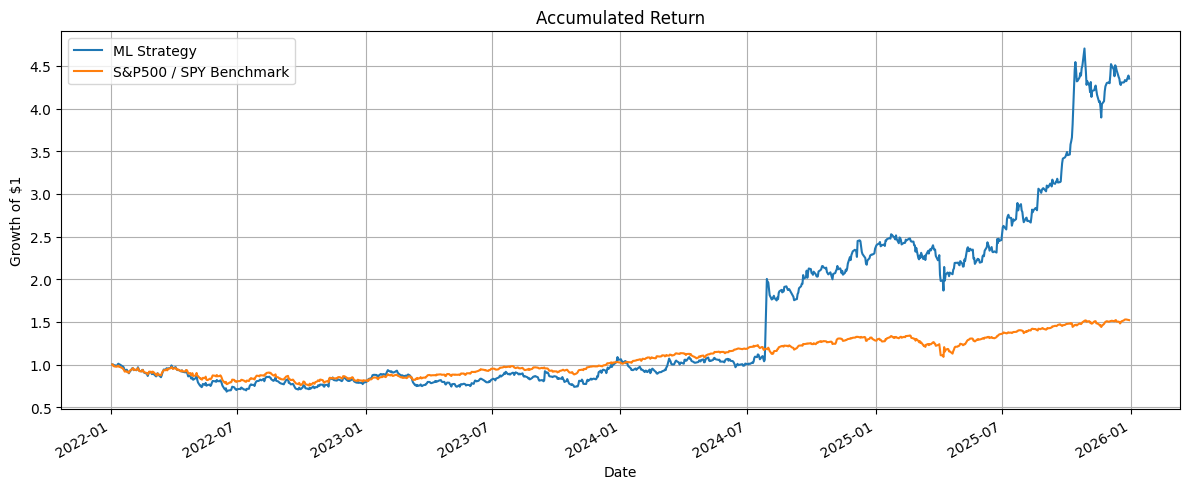

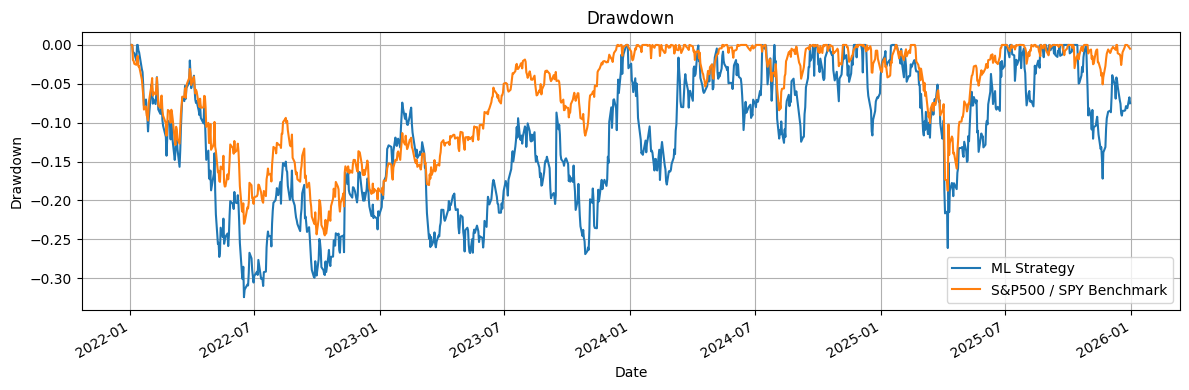

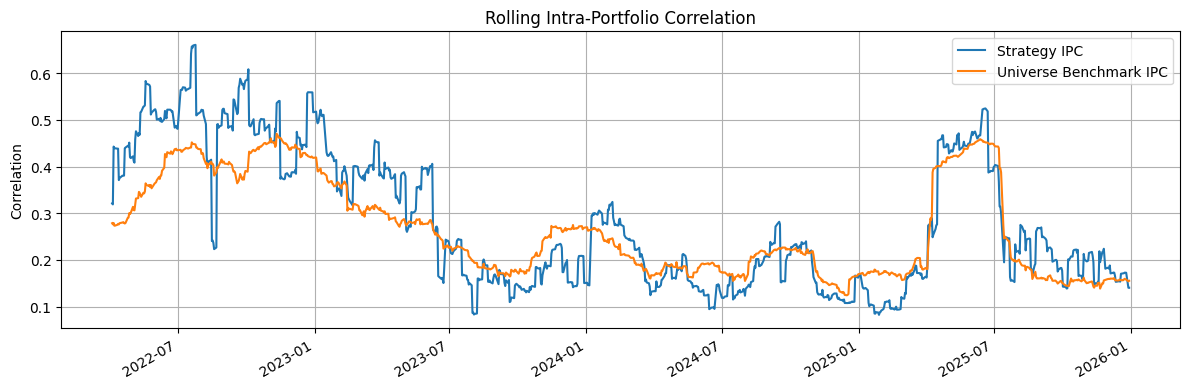

In [31]:
plt.figure(figsize=(12, 5))
(bt["equity"] / INIT_CASH).plot(label="ML Strategy")
(bench["equity"] / INIT_CASH).plot(label="S&P500 / SPY Benchmark")
plt.title("Accumulated Return")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "equity_curve_notebook.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 4))
bt["drawdown"].plot(label="ML Strategy")
bench["drawdown"].plot(label="S&P500 / SPY Benchmark")
plt.title("Drawdown")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "drawdown_notebook.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 4))
ipc_df.plot(ax=plt.gca())
plt.title("Rolling Intra-Portfolio Correlation")
plt.ylabel("Correlation")
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "ipc_notebook.png", dpi=150)
plt.show()

In [32]:
metrics_payload = {
    "strategy_metrics": strategy_metrics,
    "benchmark_metrics": benchmark_metrics,
    "cv_report": cv_report.to_dict(orient="records"),
    "cpcv_report": cpcv_report.to_dict(orient="records"),
    "notes": {
        "transaction_cost": TRANSACTION_COST,
        "init_cash": INIT_CASH,
        "no_leverage_check_max_gross_exposure": strategy_metrics["Max Gross Exposure"],
        "max_drawdown_limit": "< 20%",
        "max_drawdown_period_limit": "< 6 months",
    },
}

with open(METRICS_DIR / "research_notebook_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=4, default=str)

comparison.to_csv(METRICS_DIR / "performance_comparison_notebook.csv")
cv_report.to_csv(METRICS_DIR / "purged_kfold_report.csv", index=False)
cpcv_report.to_csv(METRICS_DIR / "cpcv_report.csv", index=False)
ipc_df.to_csv(METRICS_DIR / "ipc_dynamics.csv")

print("Saved artifacts to:")
print(PLOTS_DIR)
print(METRICS_DIR)

Saved artifacts to:
/Users/ilacvetkov/SOQ/MFT/HW2/school-of-quants-classroom-25-26-mid-frequency-trading-project-3-portfolio-optimisation-portfolio_op-main/equity_project/artifacts/plots
/Users/ilacvetkov/SOQ/MFT/HW2/school-of-quants-classroom-25-26-mid-frequency-trading-project-3-portfolio-optimisation-portfolio_op-main/equity_project/artifacts/metrics


## 15. Backtest constraints checklist

In [33]:
checks = {
    "Total return > 0": strategy_metrics["Accumulated Return"] > 0,
    "Max drawdown < 20%": strategy_metrics["Maximum Drawdown"] > -0.20,
    "Max drawdown period < 6M approx 183 days": strategy_metrics["Maximum Drawdown Period Days"] < 183,
    "No leverage, max gross exposure <= 1.0001": strategy_metrics["Max Gross Exposure"] <= 1.0001,
    "Uses ML model": True,
    "Uses PurgedKFold": True,
    "Uses CPCV": True,
    "Transaction cost included": abs(TRANSACTION_COST - 0.001) < 1e-12,
}

print(pd.Series(checks, name="Passed"))

Total return > 0                              True
Max drawdown < 20%                           False
Max drawdown period < 6M approx 183 days     False
No leverage, max gross exposure <= 1.0001     True
Uses ML model                                 True
Uses PurgedKFold                              True
Uses CPCV                                     True
Transaction cost included                     True
Name: Passed, dtype: bool
